In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif, RFE, RFECV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.decomposition import PCA

In [43]:
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_PCA_paul.xlsx"
df = pd.read_excel(dataset_total_path)
df = df.groupby(by = 'Class', as_index=False).mean()
df.head()

,Class,(-)-Caryophyllene oxide,(-)-Citronellal,(-)-Isopulegol,(+/-)-6-Acetonyldihydrosanguinarine,(+/-)9-HpODE,"(12Z)-9,10,11-trihydroxyoctadec-12-enoic acid","(13S,14R)-1,8-Dihydroxy-13-O-acetyl-N-methylcanadine","(1R,2R)-3-oxo-2-pentyl-cyclopentanebutanoic acid","(20S,24S)-24-ethylthornasterol",...,Xanthotoxol,Zeatin-7-N-glucoside,Zizybeoside II,alpha-Linolenic acid,Benzoylformic acid,Columbianetin,N-Acetyl-alpha-D-glucosamine 1-phosphate,Sinapic acid,Formononetin,3-O-Feruloylquinic acid
0,LN,1.591455e+07,6.980138e+07,5.631014e+07,1.449034e+08,4.335375e+06,8.535153e+06,1.766983e+06,2.648956e+08,4.355494e+06,...,1.917533e+08,6.317868e+06,1.274049e+06,5.253667e+06,2.343000e+05,4.905842e+05,8.362977e+06,6.966639e+06,3.966079e+08,2.511707e+08
1,LP,2.952731e+07,4.659259e+07,1.455664e+08,1.789006e+08,8.626689e+06,8.261674e+06,1.720943e+06,2.538358e+08,1.398658e+06,...,1.207291e+08,6.627147e+06,1.473754e+06,4.867268e+06,2.831692e+05,9.280400e+05,1.237247e+07,2.034974e+07,2.523361e+08,2.769312e+08
2,SN,3.621271e+06,1.318311e+07,3.954817e+06,5.627351e+07,3.468366e+07,4.204084e+06,9.390267e+06,8.327545e+08,1.263292e+07,...,8.870022e+04,2.195873e+07,1.667904e+07,8.685080e+06,1.693340e+07,1.256723e+07,4.931866e+06,2.629140e+06,8.928560e+04,6.432403e+05
3,SP,6.650474e+06,5.141848e+06,4.719063e+06,6.386797e+07,2.463304e+07,6.653567e+06,1.203525e+07,1.060611e+09,4.606290e+06,...,1.298454e+05,3.178792e+07,1.202847e+07,5.030197e+06,1.631896e+07,2.001037e+07,6.717366e+06,5.442586e+06,1.354435e+05,1.160512e+06


# Convertion en log2

In [44]:
def encodage(df):
    code = {
    'LP' : 'Lemon\ninoculated',
    'SP' : 'Orange\ninoculated',
    'LN' : 'Lemon\ncontrol',
    'SN' : 'Orange\ncontrol'
}
    # Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df

encodage(df)
df = df.set_index('Class')
print(df.shape)
df.head()

(4, 375)


,(-)-Caryophyllene oxide,(-)-Citronellal,(-)-Isopulegol,(+/-)-6-Acetonyldihydrosanguinarine,(+/-)9-HpODE,"(12Z)-9,10,11-trihydroxyoctadec-12-enoic acid","(13S,14R)-1,8-Dihydroxy-13-O-acetyl-N-methylcanadine","(1R,2R)-3-oxo-2-pentyl-cyclopentanebutanoic acid","(20S,24S)-24-ethylthornasterol","(2R,3S,4S,5R,6R)-2-(hydroxymethyl)-6-(2-phenylethoxy)oxane-3,4,5-triol",...,Xanthotoxol,Zeatin-7-N-glucoside,Zizybeoside II,alpha-Linolenic acid,Benzoylformic acid,Columbianetin,N-Acetyl-alpha-D-glucosamine 1-phosphate,Sinapic acid,Formononetin,3-O-Feruloylquinic acid
Class,,,,,,,,,,,,,,,,,,,,,
Lemon\ncontrol,1.591455e+07,6.980138e+07,5.631014e+07,1.449034e+08,4.335375e+06,8.535153e+06,1.766983e+06,2.648956e+08,4.355494e+06,9.664745e+06,...,1.917533e+08,6.317868e+06,1.274049e+06,5.253667e+06,2.343000e+05,4.905842e+05,8.362977e+06,6.966639e+06,3.966079e+08,2.511707e+08
Lemon\ninoculated,2.952731e+07,4.659259e+07,1.455664e+08,1.789006e+08,8.626689e+06,8.261674e+06,1.720943e+06,2.538358e+08,1.398658e+06,1.363532e+07,...,1.207291e+08,6.627147e+06,1.473754e+06,4.867268e+06,2.831692e+05,9.280400e+05,1.237247e+07,2.034974e+07,2.523361e+08,2.769312e+08
Orange\ncontrol,3.621271e+06,1.318311e+07,3.954817e+06,5.627351e+07,3.468366e+07,4.204084e+06,9.390267e+06,8.327545e+08,1.263292e+07,6.627322e+06,...,8.870022e+04,2.195873e+07,1.667904e+07,8.685080e+06,1.693340e+07,1.256723e+07,4.931866e+06,2.629140e+06,8.928560e+04,6.432403e+05
Orange\ninoculated,6.650474e+06,5.141848e+06,4.719063e+06,6.386797e+07,2.463304e+07,6.653567e+06,1.203525e+07,1.060611e+09,4.606290e+06,1.585956e+07,...,1.298454e+05,3.178792e+07,1.202847e+07,5.030197e+06,1.631896e+07,2.001037e+07,6.717366e+06,5.442586e+06,1.354435e+05,1.160512e+06


In [45]:
print('var before log2 : ', df.var(axis=0).median())
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
df_log = log2_transformer.fit_transform(df)
print('var after log2 : ', df_log.var(axis=0).median())
df_log['Cornuside']

var before log2 :  198967719052235.47
var after log2 :  2.288714780117832


Class
Lemon\ncontrol        22.588850
Lemon\ninoculated     24.006549
Orange\ncontrol       19.383576
Orange\ninoculated    19.408854
Name: Cornuside, dtype: float64

In [5]:
#df_log.to_excel('C:/Users/tamer/Documents/PhD/ML/Metabolome_log2.xlsx')

# Extracting metabolite names per class / subclass

In [51]:
dataset_names_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_PCA_subclass.xlsx"
df_names = pd.read_excel(dataset_names_path)

subclass = "Flavonoids"
level = 'Second'

df_names = df_names.set_index('Class')
mask = df_names.loc[level] == subclass
df_names = df_names.loc[:, mask]
df_names = df_names.reset_index()
df_names.head()

df_names = df_names.iloc[3:]

metabolites = df_names.columns[1:]

# Heatmap for the map

In [52]:
CA = ["L-Tyrosine","L-Phenylalanine","Sinapic acid","Ferulic acid","Ferulaldehyde","Cinnamic acid","p-Coumaric acid","Syringin","Coniferin","Methyl eugenol"]

metabolites = CA

# Heatmap for abundance per class

In [53]:
df_plot = df_log[metabolites]

color = sns.color_palette("Spectral", as_cmap=True)
#color = 'vlag'

g = sns.clustermap(df_plot.T,
                   cmap= "vlag",
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

g.fig.suptitle(
    f"{subclass} abundance heatmap",
    fontsize=18,
    y=0.85  
)
g.cax.set_position([1, 0.8, 0.02, 0.15])
g.ax_heatmap.set_xlabel("")

plt.savefig("C:/Users/tamer/Documents/PhD/ML/HM_4.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/HM_4.png", dpi=600, bbox_inches="tight")   

g.cax.tick_params(labelsize=10)


KeyError: "['Ferulaldehyde', 'Coniferin', 'Methyl eugenol'] not in index"

In [39]:
g.fig.savefig(f"C:/Users/tamer/Documents/PhD/ML/heatmap/{subclass}heatmap.png", dpi=600, bbox_inches="tight")
g.fig.savefig(f"C:/Users/tamer/Documents/PhD/ML/heatmap/{subclass}heatmap.pdf", dpi=600, bbox_inches="tight")

# Heatmap for abundance ALL samples

In [9]:
dataset_total_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_PCA_paul.xlsx"
df = pd.read_excel(dataset_total_path)
df.head()

,Class,(-)-Caryophyllene oxide,(-)-Citronellal,(-)-Isopulegol,(+/-)-6-Acetonyldihydrosanguinarine,(+/-)9-HpODE,"(12Z)-9,10,11-trihydroxyoctadec-12-enoic acid","(13S,14R)-1,8-Dihydroxy-13-O-acetyl-N-methylcanadine","(1R,2R)-3-oxo-2-pentyl-cyclopentanebutanoic acid","(20S,24S)-24-ethylthornasterol",...,Xanthotoxol,Zeatin-7-N-glucoside,Zizybeoside II,alpha-Linolenic acid,Benzoylformic acid,Columbianetin,N-Acetyl-alpha-D-glucosamine 1-phosphate,Sinapic acid,Formononetin,3-O-Feruloylquinic acid
0,LN,2.051442e+07,8.225398e+07,5.951537e+07,1.442574e+08,3.915938e+06,6.484714e+06,1.845702e+06,3.409089e+08,2.979843e+06,...,1.592319e+08,6.977597e+06,1.321413e+06,1.648676e+06,246281.718395,311136.697876,8.755011e+06,6.428733e+06,3.322790e+08,2.893708e+08
1,LN,1.604440e+07,6.576795e+07,6.565860e+07,1.395342e+08,3.455438e+06,7.645172e+06,9.266096e+05,2.814200e+08,4.246855e+06,...,1.839517e+08,6.475681e+06,9.090720e+05,8.428185e+06,260301.552157,707409.525035,7.551689e+06,8.477317e+06,3.802351e+08,2.926707e+08
2,LN,1.281209e+07,7.537021e+07,4.898186e+07,1.617739e+08,4.861781e+06,9.360360e+06,2.251724e+06,2.559719e+08,5.950179e+06,...,2.060834e+08,5.968876e+06,1.775050e+06,6.358632e+06,227397.587228,442253.434641,8.264441e+06,7.303508e+06,4.255267e+08,2.338365e+08
3,LN,1.280219e+07,7.423449e+07,4.378585e+07,1.525341e+08,4.623925e+06,1.004368e+07,2.213574e+06,2.461972e+08,5.971395e+06,...,2.371304e+08,5.846398e+06,1.280571e+06,7.084423e+06,218759.688123,669404.547424,8.844958e+06,7.492052e+06,4.972550e+08,2.375650e+08
4,LN,1.714193e+07,5.667193e+07,7.538867e+07,1.271462e+08,5.560945e+06,8.275192e+06,1.636707e+06,2.476864e+08,2.652215e+06,...,1.624333e+08,6.370606e+06,1.197590e+06,6.135651e+06,225264.346637,300690.268693,7.216139e+06,7.123495e+06,3.318643e+08,2.382407e+08


In [10]:
def encodage(df):
    code = {
    'LP' : 'Lemon\ninoculated',
    'SP' : 'Orange\ninoculated',
    'LN' : 'Lemon\ncontrol',
    'SN' : 'Orange\ncontrol'
}
    # Appliquer ce dictionnaire aux colonnes du dataset, avec la fonction map
    for col in df.select_dtypes('object'):
        df[col] = df[col].map(code)

    return df

encodage(df)
df = df.set_index('Class')
print(df.shape)
df.head()

(24, 375)


,(-)-Caryophyllene oxide,(-)-Citronellal,(-)-Isopulegol,(+/-)-6-Acetonyldihydrosanguinarine,(+/-)9-HpODE,"(12Z)-9,10,11-trihydroxyoctadec-12-enoic acid","(13S,14R)-1,8-Dihydroxy-13-O-acetyl-N-methylcanadine","(1R,2R)-3-oxo-2-pentyl-cyclopentanebutanoic acid","(20S,24S)-24-ethylthornasterol","(2R,3S,4S,5R,6R)-2-(hydroxymethyl)-6-(2-phenylethoxy)oxane-3,4,5-triol",...,Xanthotoxol,Zeatin-7-N-glucoside,Zizybeoside II,alpha-Linolenic acid,Benzoylformic acid,Columbianetin,N-Acetyl-alpha-D-glucosamine 1-phosphate,Sinapic acid,Formononetin,3-O-Feruloylquinic acid
Class,,,,,,,,,,,,,,,,,,,,,
Lemon\ncontrol,2.051442e+07,8.225398e+07,5.951537e+07,1.442574e+08,3.915938e+06,6.484714e+06,1.845702e+06,3.409089e+08,2.979843e+06,1.115132e+07,...,1.592319e+08,6.977597e+06,1.321413e+06,1.648676e+06,246281.718395,311136.697876,8.755011e+06,6.428733e+06,3.322790e+08,2.893708e+08
Lemon\ncontrol,1.604440e+07,6.576795e+07,6.565860e+07,1.395342e+08,3.455438e+06,7.645172e+06,9.266096e+05,2.814200e+08,4.246855e+06,1.123199e+07,...,1.839517e+08,6.475681e+06,9.090720e+05,8.428185e+06,260301.552157,707409.525035,7.551689e+06,8.477317e+06,3.802351e+08,2.926707e+08
Lemon\ncontrol,1.281209e+07,7.537021e+07,4.898186e+07,1.617739e+08,4.861781e+06,9.360360e+06,2.251724e+06,2.559719e+08,5.950179e+06,6.949881e+06,...,2.060834e+08,5.968876e+06,1.775050e+06,6.358632e+06,227397.587228,442253.434641,8.264441e+06,7.303508e+06,4.255267e+08,2.338365e+08
Lemon\ncontrol,1.280219e+07,7.423449e+07,4.378585e+07,1.525341e+08,4.623925e+06,1.004368e+07,2.213574e+06,2.461972e+08,5.971395e+06,1.028470e+07,...,2.371304e+08,5.846398e+06,1.280571e+06,7.084423e+06,218759.688123,669404.547424,8.844958e+06,7.492052e+06,4.972550e+08,2.375650e+08
Lemon\ncontrol,1.714193e+07,5.667193e+07,7.538867e+07,1.271462e+08,5.560945e+06,8.275192e+06,1.636707e+06,2.476864e+08,2.652215e+06,1.015237e+07,...,1.624333e+08,6.370606e+06,1.197590e+06,6.135651e+06,225264.346637,300690.268693,7.216139e+06,7.123495e+06,3.318643e+08,2.382407e+08


In [11]:
print('var before log2 : ', df.var(axis=0).median())
log2_transformer = FunctionTransformer(lambda x: np.log2(x + 1))
df_log = log2_transformer.fit_transform(df)
print('var after log2 : ', df_log.var(axis=0).median())
df_log['Cornuside']

var before log2 :  220887286790013.78
var after log2 :  2.280142391017543


Class
Lemon\ncontrol        22.163316
Lemon\ncontrol        22.477959
Lemon\ncontrol        22.591974
Lemon\ncontrol        22.969197
Lemon\ncontrol        22.426573
Lemon\ncontrol        22.767706
Lemon\ninoculated     24.046126
Lemon\ninoculated     23.961627
Lemon\ninoculated     24.088603
Lemon\ninoculated     24.131368
Lemon\ninoculated     24.227490
Lemon\ninoculated     23.467991
Orange\ncontrol       19.605604
Orange\ncontrol       19.427622
Orange\ncontrol       19.358777
Orange\ncontrol       19.348643
Orange\ncontrol       19.279663
Orange\ncontrol       19.252402
Orange\ninoculated    19.579087
Orange\ninoculated    19.321256
Orange\ninoculated    19.658433
Orange\ninoculated    19.422072
Orange\ninoculated    19.165825
Orange\ninoculated    19.241766
Name: Cornuside, dtype: float64

In [12]:
dataset_names_path = "C:/Users/tamer/Documents/PhD/ML/Metabolome_PCA_subclass.xlsx"
df_names = pd.read_excel(dataset_names_path)

subclass = "Terpenoids"
level = 'First'

df_names = df_names.set_index('Class')
mask = df_names.loc[level] == subclass
df_names = df_names.loc[:, mask]
df_names = df_names.reset_index()
df_names.head()

df_names = df_names.iloc[3:]

metabolites = df_names.columns[1:]


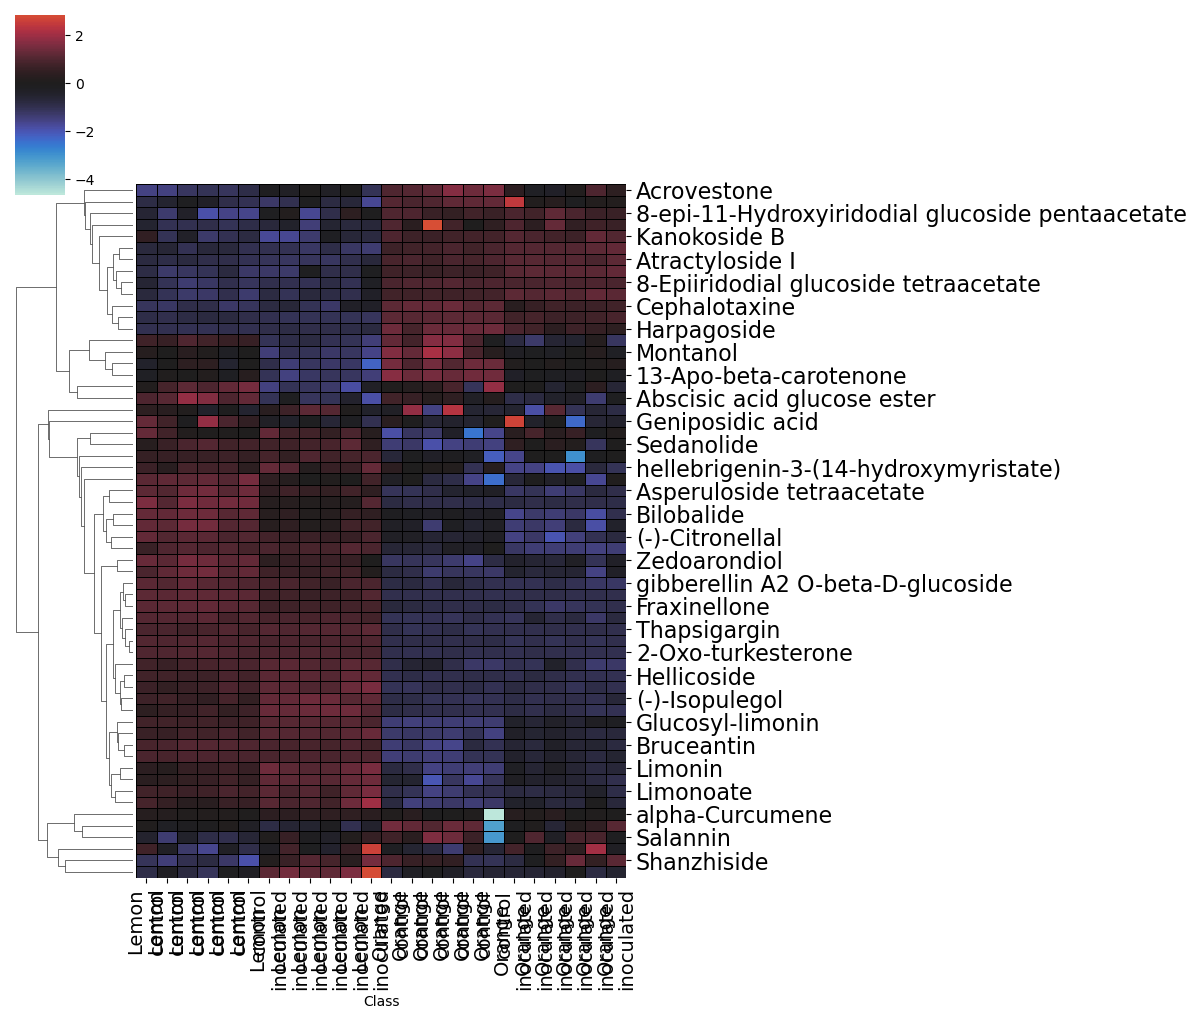

In [13]:
df_plot = df_log[metabolites]

color = sns.diverging_palette(220, 20, as_cmap=True)
#color = 'vlag'

g = sns.clustermap(df_plot.T,
                   #cmap= color,
                   col_cluster = False,
                   #standard_scale=0,
                   z_score=0,
                   center=0,
                   linewidths=0.5,
                   linecolor="black")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=14) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=16)

plt.savefig("C:/Users/tamer/Documents/PhD/ML/HM_24.pdf", format="pdf", bbox_inches="tight")   
plt.savefig("C:/Users/tamer/Documents/PhD/ML/HM_24.png", dpi=600, bbox_inches="tight")

g.cax.tick_params(labelsize=10)

# Heatmap for Log2FC

In [14]:
path = "C:/Users/tamer/Documents/PhD/ML/metabolome_log2FC.xlsx"

df_FC = pd.read_excel(path)
df_FC = df_FC.set_index('Metabolites')
df_FC.head()

,Pheophorbide a,Nobiletin,Sinensetin,Adenosine,D-(-)-Quinic acid,Corchorifatty acid F,O-Feruloylgalactarate,3-Coumaric acid,Citric acid,Vicenin II,...,Luteolin 7-(6''-p-benzoyglucoside),13-Apo-beta-carotenone,hellebrigenin-3-(14-hydroxymyristate),"Quercetin 3,3'-dimethyl ether 7-rutinoside",Plantamajoside,N-Acetylornithine,"2,2-Dimethyl-8-prenylchromene 6-carboxylic acid",Abietic Acid,Myricetin,N-Methyltryptamine
Metabolites,,,,,,,,,,,,,,,,,,,,,
Lemon control vs Orange control,-0.003459,-11.730942,-12.463218,0.776586,2.399089,2.008165,-1.155110,9.967541,-2.457705,-2.904809,...,4.959670,-2.722442,1.244177,-3.702652,4.205261,2.802467,-0.068168,-5.291325,-1.317209,0.064652
Lemon HLB vs Orange HLB,-1.884728,-10.810619,-10.873386,0.098615,4.031375,1.120849,-1.210463,8.765776,-2.037849,-2.823962,...,5.409258,-1.980880,4.837442,-2.577251,4.863103,1.055402,2.675273,-3.094373,0.346668,3.903859
Lemon control vs lemon HLB,-2.087995,0.546836,1.218819,-0.507039,-0.093802,-0.625386,0.085077,-0.303921,-0.875011,0.189522,...,0.488328,-2.412424,0.582321,0.240442,1.360695,-2.048321,2.731616,0.360996,0.190509,3.795252
Orange control vs Orange HLB,-0.206727,-0.373487,-0.371012,0.170932,-1.726088,0.261931,0.140430,0.897845,-1.294867,0.108675,...,0.038740,-3.153987,-3.010944,-0.884959,0.702852,-0.301256,-0.011825,-1.835956,-1.473368,-0.043955


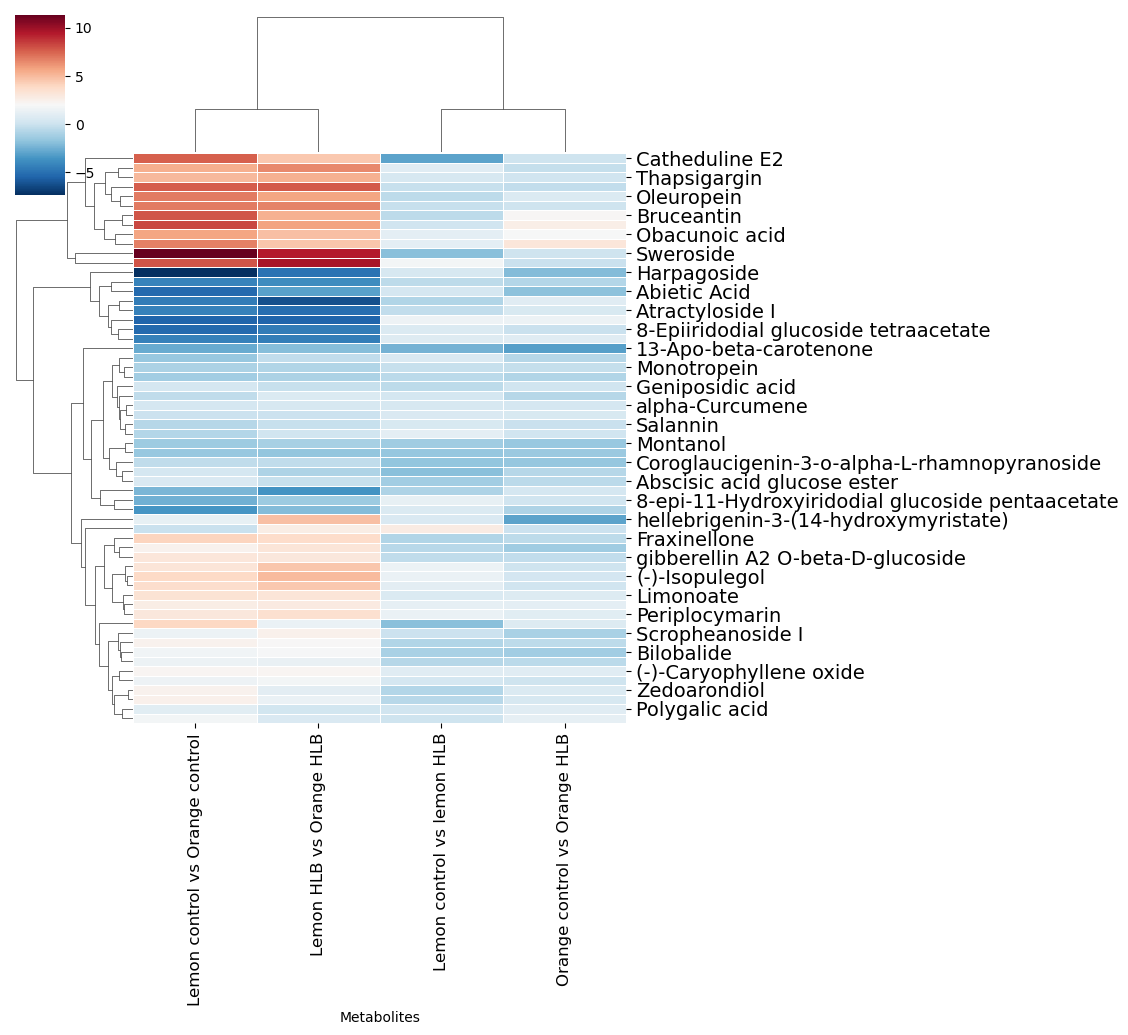

In [15]:
df_FC = df_FC[metabolites]
g = sns.clustermap(df_FC.T,
                   cmap="RdBu_r",
                   #standard_scale=0,
                   linewidths=0.5,
                   linecolor="white")

plt.setp(g.ax_heatmap.get_xticklabels(), fontsize=12) 
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=14)

g.cax.tick_params(labelsize=10)

#plt.setp(g.ax_heatmap.get_yticklabels(), rotation=180)

In [16]:
g.fig.savefig("C:/Users/tamer/Documents/PhD/ML/HM_Lo2FC.png", dpi=600, bbox_inches="tight")